# Vignette 2: Analysis of ESR1 D538G Mutations in Surgical Samples

This vignette demonstrates the analysis of spatial transcriptomics data from a surgical sample containing ESR1 D538G mutations, a common mutation in breast cancer. The analysis combines CITEgeist deconvolution with pathway analysis and mutation signature validation.

For this vignette we recommend running it from top to bottom as it uses a lower min_count cutoff than the sbatch default setting.

In [33]:
# USER DEFINED VARIABLES

LICENSE_FILE = "/ihome/crc/install/gurobi/gurobi1102/linux64/lic/gurobi.lic"
DATA_FOLDER = "/bgfs/alee/LO_LAB/General/Lab_Data/20250210_CITEGeistPublicData_GEO_Alex/processed_files/"


In [34]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [35]:
import multiprocessing

# Get the number of CPUs
num_cpus = multiprocessing.cpu_count()
print(f"Number of CPUs available: {num_cpus}")


Number of CPUs available: 48


In [36]:
import psutil   

# Get memory information
mem = psutil.virtual_memory()
total_memory = mem.total / (1024 ** 3)  # Convert bytes to GB
available_memory = mem.available / (1024 ** 3)  # Convert bytes to GB

print(f"Total Memory: {total_memory:.2f} GB")
print(f"Available Memory: {available_memory:.2f} GB")


Total Memory: 754.52 GB
Available Memory: 724.10 GB


In [37]:
import sys
import os
import importlib

sys.path.insert(0, os.path.abspath('..'))



## Initial Setup and Data Processing

We begin by loading necessary Python packages and setting up the computational environment. The analysis uses CITEgeist to process spatial transcriptomics data from a surgical sample, performing deconvolution using a predefined set of cell type markers for various cell populations including cancer cells, immune cells, and stromal cells.

In [38]:
import scanpy as sc
import importlib
import model
importlib.reload(model)
from model import CitegeistModel  # Now directly import from the module
import seaborn as sns

# Reload the model module if you're actively developing

path_to_biopsy = os.path.join(DATA_FOLDER, "HCC22-088-P4-S1/outs")

path_to_surgical = os.path.join(DATA_FOLDER, "HCC22-088-P4-S2_1i_rep/outs") # Due to QC issues, this sample was re-run


path_list = [path_to_biopsy, path_to_surgical]

## Cell Type Profile Definition

We define comprehensive cell profiles that specify antibody markers for each cell type:
- Cancer Cells: EPCAM-1 (major), SDC1-1 and KRT5-1 (minor)
- Immune Cells: Various markers for macrophages, T cells, and B cells
- Stromal Cells: Markers for endothelial cells and fibroblasts

These profiles are crucial for accurate deconvolution of the spatial transcriptomics data.

In [39]:
cell_profiles = {
    "Cancer Cells": {
        "Major": ["EPCAM-1"],
        "Minor": ["SDC1-1",  "KRT5-1"]  # CD138 - possible cancer stem cell marker
    },
    "Macrophages": {
        "Major": ["CD68-1" ],  # General macrophage and M2-polarized macrophages
        "Minor": ["CD14-1"]  # Monocyte/macrophage lineage marker
    },
    "CD4 T Cells": {
        "Major": ["CD3E-1", "CD4-1"],  # General, Helper, and Cytotoxic T cells
    },
    "CD8 T Cells": {
        "Major": ["CD3E-1", "CD8A-1"],  # General, Helper, and Cytotoxic T cells
    },
    "B Cells": {
        "Major": ["MS4A1-1", "CD19-1"],  # General B cell markers and developmental marker
    },
    "Endothelial Cells": {
        "Major": ["PECAM1-1"],  # CD31 - endothelial cell marker
    },
    "Fibroblasts": {
        "Major": ["ACTA2-1"],  # α-SMA - myofibroblast marker, indicates activated stroma
    }
}


CitegeistModel initialized successfully.
AnnData has been successfully split into 'gene_expression_adata' and 'antibody_capture_adata'.
Filtered gene expression data: 18085 → 2141 genes (count > 0 in at least 1.0% of spots, mean expression > 1.1 in nonzero spots). Remaining spots: 763 Filtered spots: 794 to 763
Antibody capture data preprocessing completed: Winsorized, CLR applied, no NaNs detected.
CitegeistModel Summary:
- Output Folder: output_cutoff_25
- Main AnnData Loaded: Yes
- Gene Expression AnnData Loaded: Yes
- Antibody Capture AnnData Loaded: Yes
- Cell Profile Dictionary Loaded: Yes
- Gene Expression Preprocessed: Yes
- Antibody Capture Preprocessed: Yes
✅ Gurobi license file has been successfully configured.
 - GRB_LICENSE_FILE: /ihome/crc/install/gurobi/gurobi1102/linux64/lic/gurobi.lic


Refining Cell Proportions: 100%|███████████████████████████████| 763/763 [02:13<00:00,  5.73it/s]
... storing 'feature_types' as categorical
... storing 'genome' as categorical
... storing 'isotype_control' as categorical
... storing 'normalized' as categorical
... storing 'pattern' as categorical
... storing 'read' as categorical
... storing 'secondary_name' as categorical
... storing 'sequence' as categorical



Before sorting:
CSV spots 1-10: ['AACACTTGGCAAGGAA-1', 'AACAGGTTATTGCACC-1', 'AACCGCGGTAACTACA-1', 'AACCTGACAGTGCCGC-1', 'AACGAAGCGTGGAAGT-1', 'AACTAGCGCTCCAGTT-1', 'AACTATGCTGCATTCG-1', 'AACTGCCTCGATAGGT-1', 'AACTTCGCTTAGTCAG-1', 'AACTTGGTTAATACTA-1']
AnnData spots 1-10: ['AACACTTGGCAAGGAA-1', 'AACAGGTTATTGCACC-1', 'AACCGCGGTAACTACA-1', 'AACCTGACAGTGCCGC-1', 'AACGAAGCGTGGAAGT-1', 'AACTAGCGCTCCAGTT-1', 'AACTATGCTGCATTCG-1', 'AACTGCCTCGATAGGT-1', 'AACTTCGCTTAGTCAG-1', 'AACTTGGTTAATACTA-1']
✅ Cell type proportions have been appended to adata.obs and results['cell_prop']
✅ Returning the internal AnnData object.


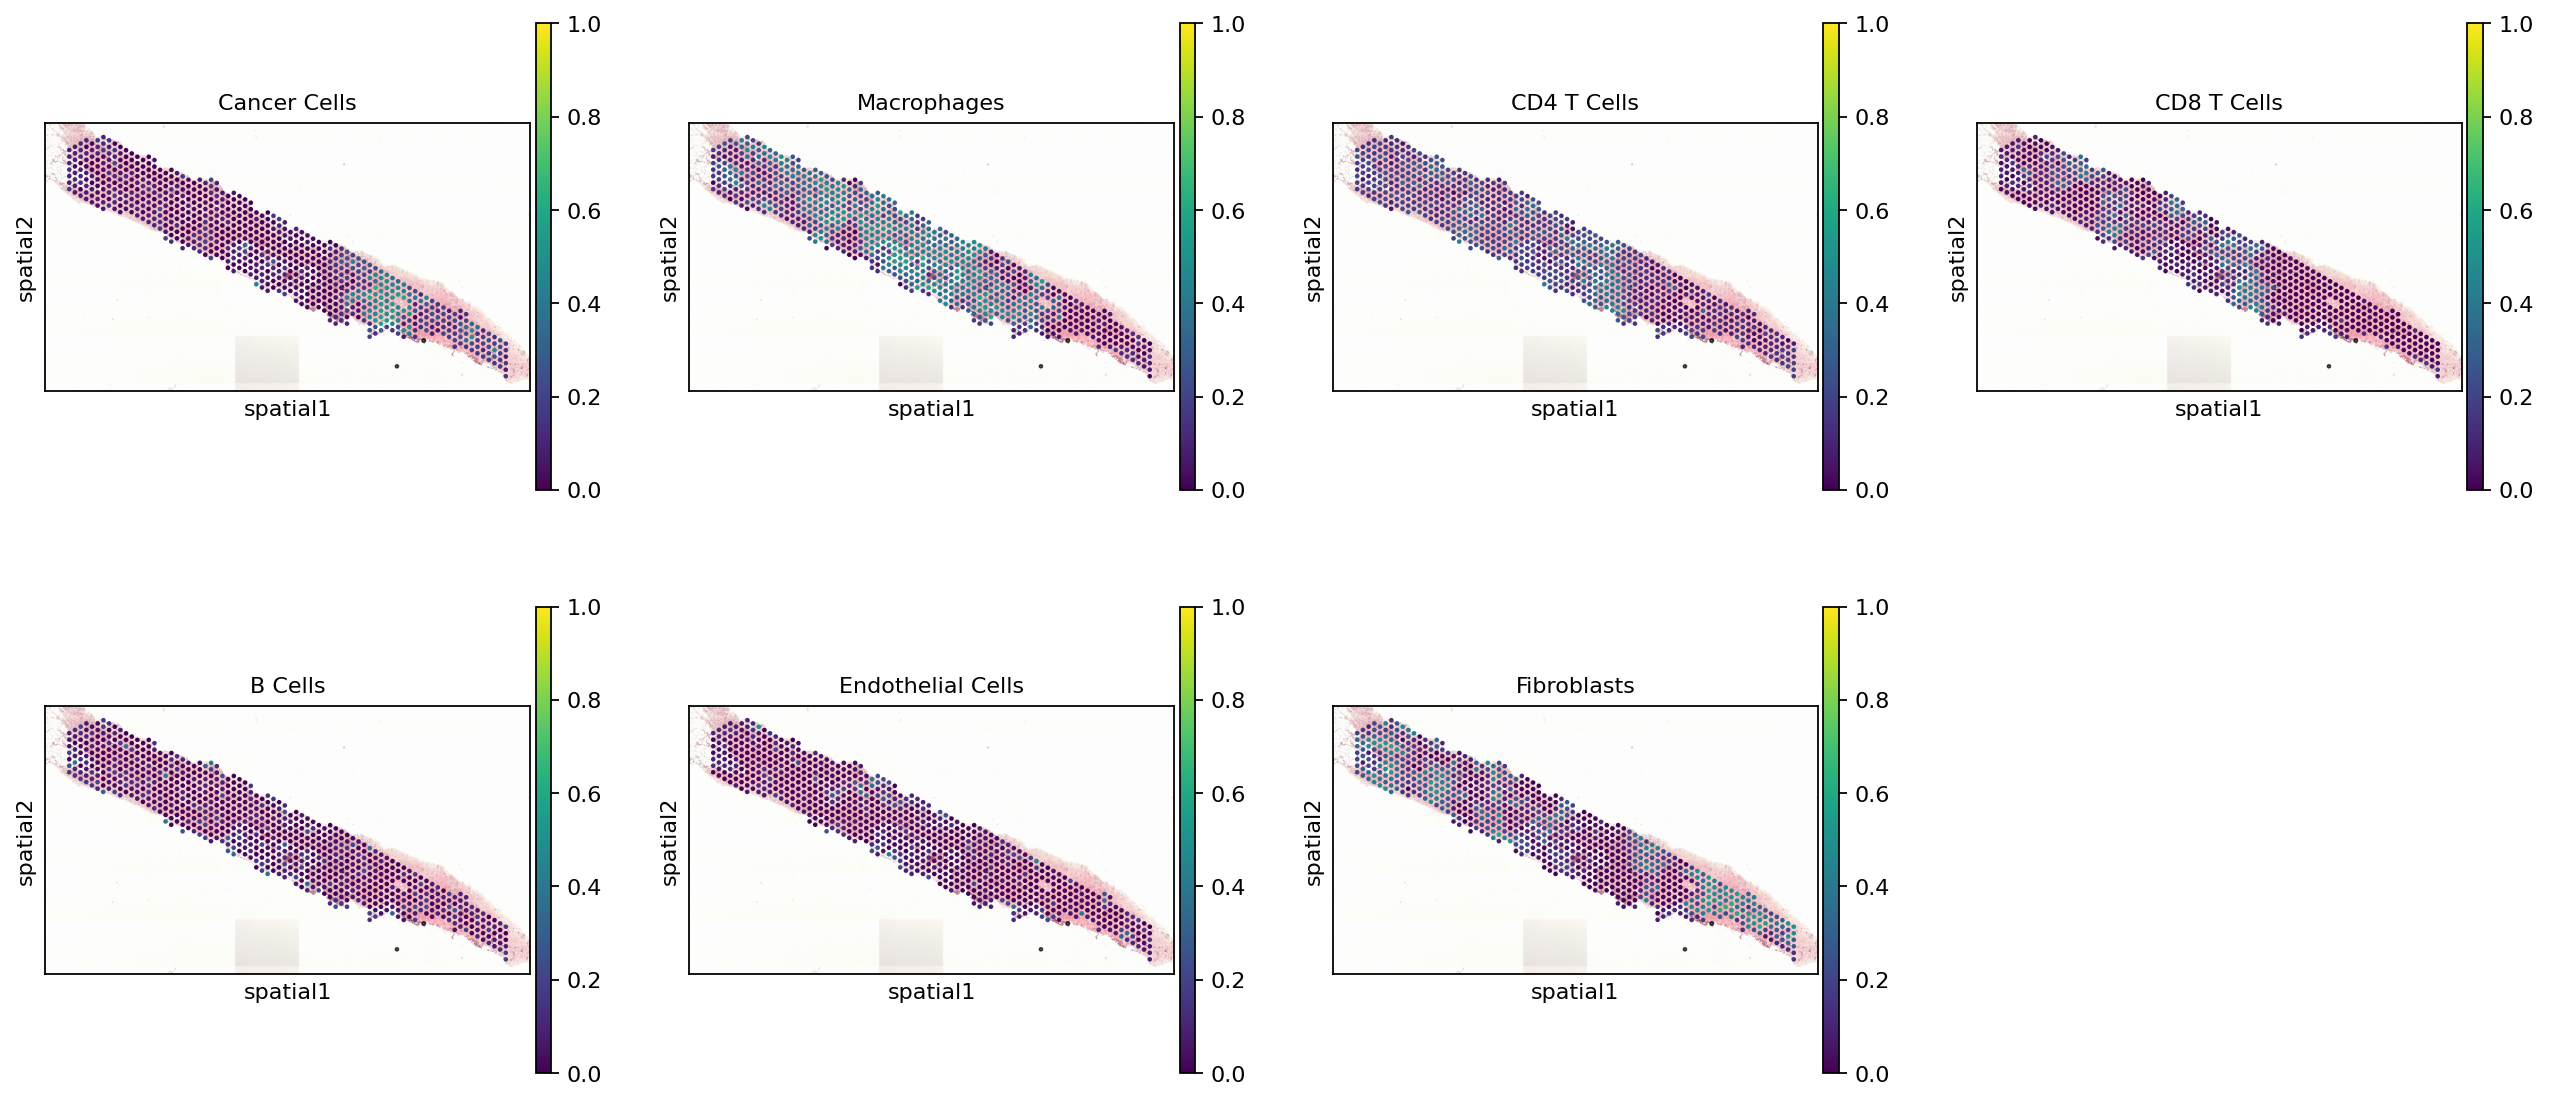

AnnData object with n_obs × n_vars = 763 × 2141
    obs: 'in_tissue', 'array_row', 'array_col', 'n_counts', 'size_factors', 'original_total', 'scaled_total', 'Cancer Cells', 'Macrophages', 'CD4 T Cells', 'CD8 T Cells', 'B Cells', 'Endothelial Cells', 'Fibroblasts'
    var: 'gene_ids', 'feature_types', 'genome', 'isotype_control', 'normalized', 'pattern', 'read', 'secondary_name', 'sequence'
    uns: 'spatial'
    obsm: 'spatial'


Deconvoluting Remaining Spots: 100%|██████████| 763/763 [00:45<00:00, 16.89it/s]


Parquet file for pass 1 loaded successfully.
Spot and CellType successfully split.

Spot name formats:
AnnData spot names format: Index(['AACACTTGGCAAGGAA-1', 'AACAGGTTATTGCACC-1', 'AACCGCGGTAACTACA-1',
       'AACCTGACAGTGCCGC-1', 'AACGAAGCGTGGAAGT-1'],
      dtype='object')
Parquet spot names format: ['AACACTTGGCAAGGAA-1' 'AACAGGTTATTGCACC-1' 'AACCGCGGTAACTACA-1'
 'AACCTGACAGTGCCGC-1' 'AACGAAGCGTGGAAGT-1']
Added layer: CD8_T_Cells_genes_pass1 (Shape: (763, 2141))
Added layer: CD4_T_Cells_genes_pass1 (Shape: (763, 2141))
Added layer: B_Cells_genes_pass1 (Shape: (763, 2141))
Added layer: Endothelial_Cells_genes_pass1 (Shape: (763, 2141))
Added layer: Cancer_Cells_genes_pass1 (Shape: (763, 2141))
Added layer: Macrophages_genes_pass1 (Shape: (763, 2141))
Added layer: Fibroblasts_genes_pass1 (Shape: (763, 2141))
Parquet file for pass 1 loaded successfully.
Spot and CellType successfully split.

Spot name formats:
AnnData spot names format: Index(['AACACTTGGCAAGGAA-1', 'AACAGGTTATTGCACC-1'

Refining Cell Proportions: 100%|██████████████████████████████████████████████████| 3370/3370 [09:44<00:00,  5.76it/s]
... storing 'feature_types' as categorical
... storing 'genome' as categorical
... storing 'isotype_control' as categorical
... storing 'normalized' as categorical
... storing 'pattern' as categorical
... storing 'read' as categorical
... storing 'secondary_name' as categorical
... storing 'sequence' as categorical



Before sorting:
CSV spots 1-10: ['AACACGTGCATCGCAC-1', 'AACACTTGGCAAGGAA-1', 'AACAGGATTCATAGTT-1', 'AACAGGTTATTGCACC-1', 'AACAGGTTCACCGAAG-1', 'AACAGTCGTGTCGCGG-1', 'AACATATTCTTGCGAA-1', 'AACATCGCGTGACCAC-1', 'AACATCTAATGACCGG-1', 'AACATGACGCAGCGTG-1']
AnnData spots 1-10: ['AACACGTGCATCGCAC-1', 'AACACTTGGCAAGGAA-1', 'AACAGGATTCATAGTT-1', 'AACAGGTTATTGCACC-1', 'AACAGGTTCACCGAAG-1', 'AACAGTCGTGTCGCGG-1', 'AACATATTCTTGCGAA-1', 'AACATCGCGTGACCAC-1', 'AACATCTAATGACCGG-1', 'AACATGACGCAGCGTG-1']
✅ Cell type proportions have been appended to adata.obs and results['cell_prop']
✅ Returning the internal AnnData object.


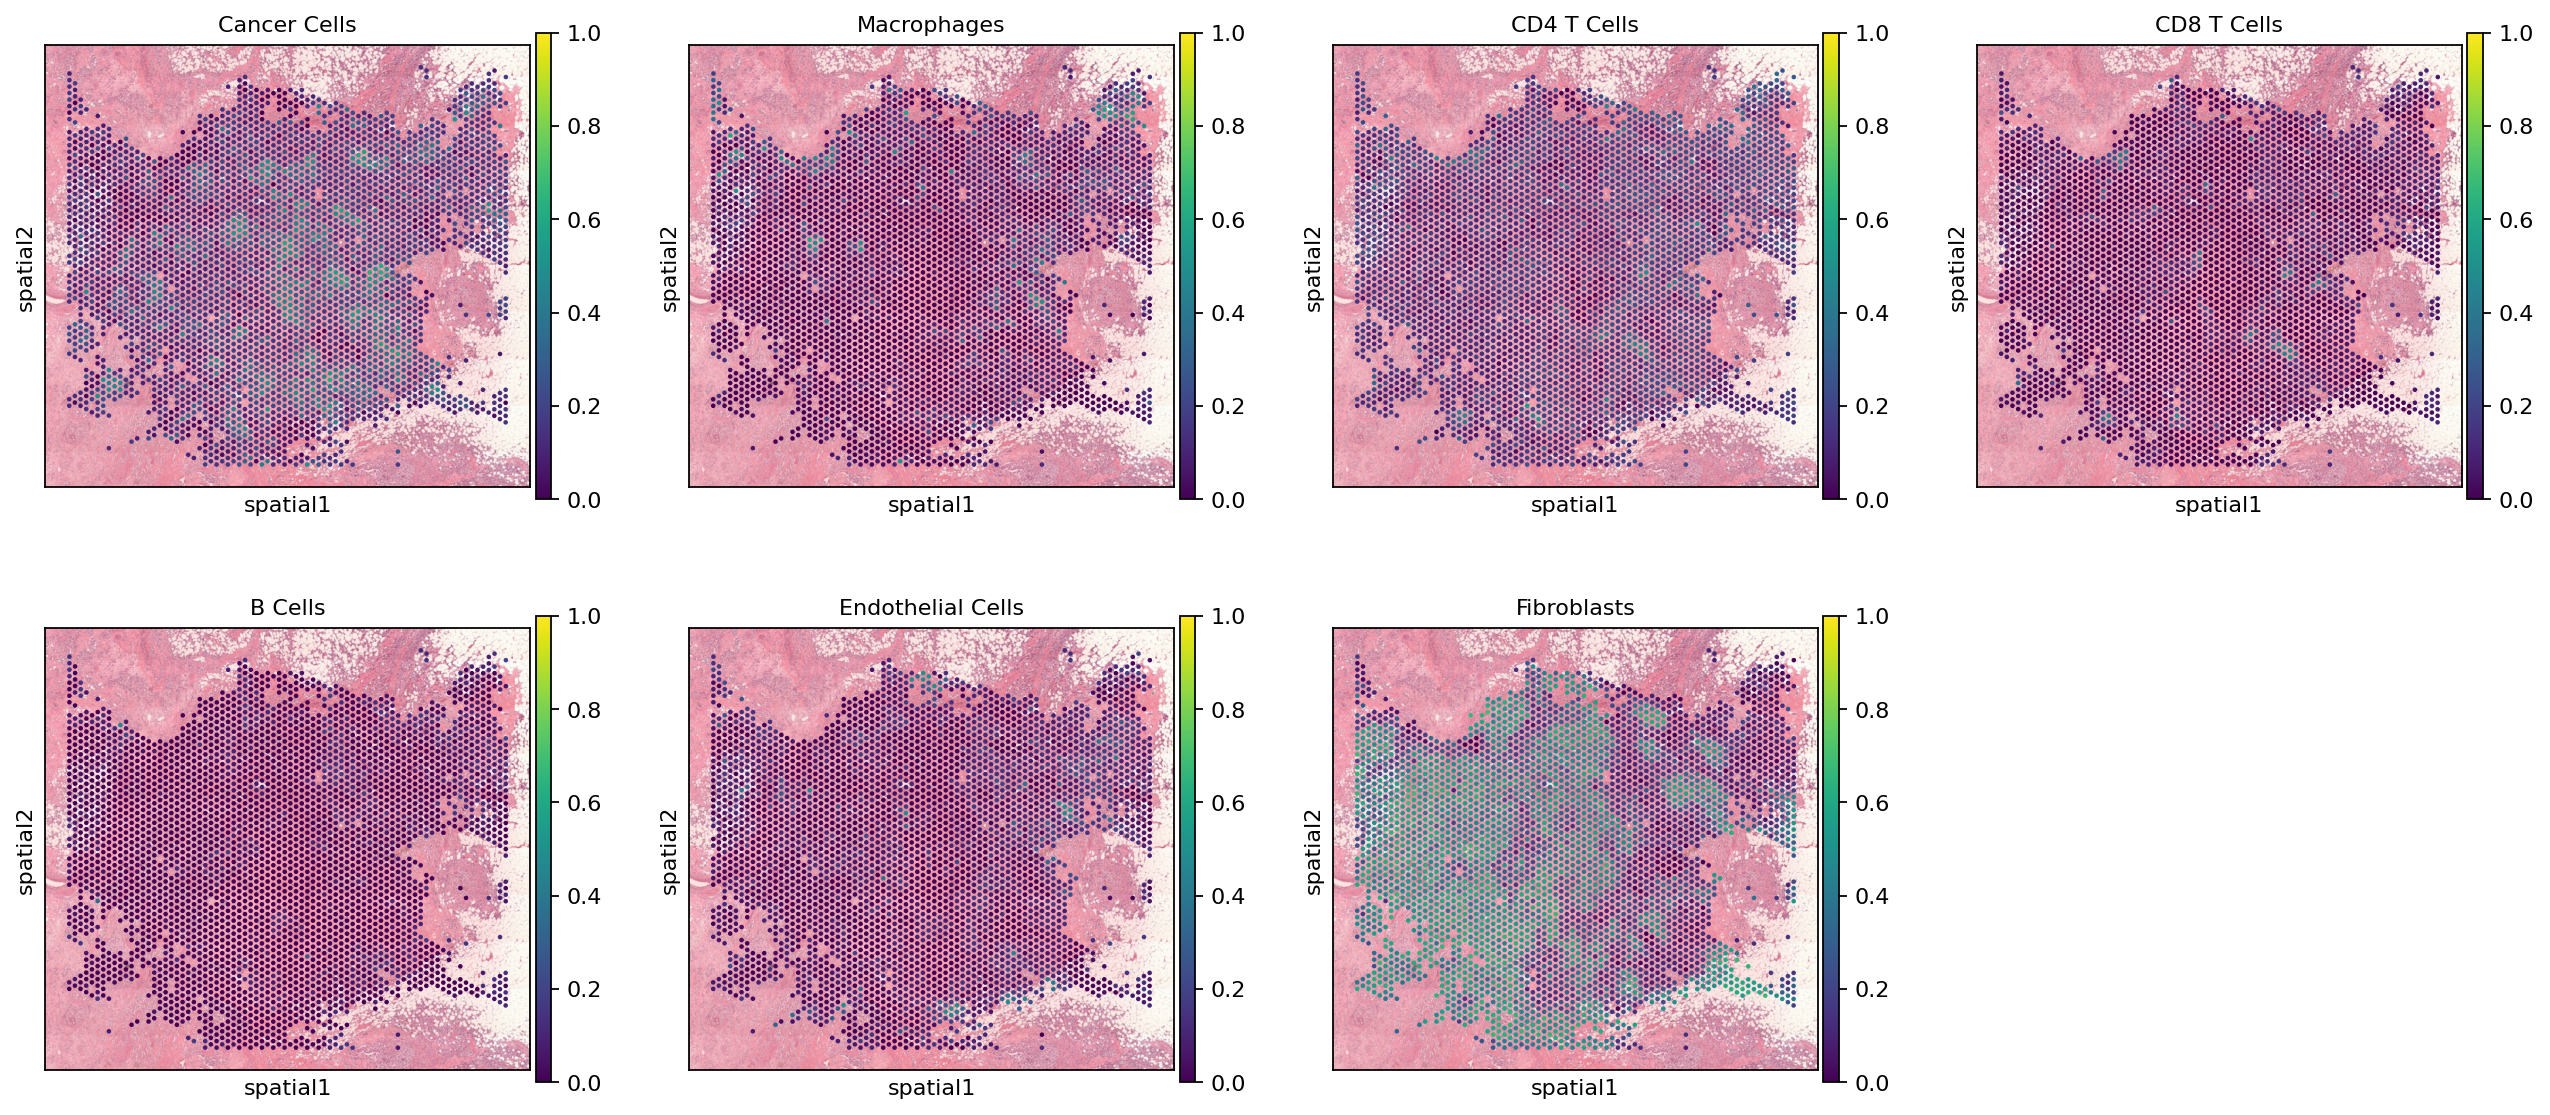

AnnData object with n_obs × n_vars = 3370 × 1771
    obs: 'in_tissue', 'array_row', 'array_col', 'n_counts', 'size_factors', 'original_total', 'scaled_total', 'Cancer Cells', 'Macrophages', 'CD4 T Cells', 'CD8 T Cells', 'B Cells', 'Endothelial Cells', 'Fibroblasts'
    var: 'gene_ids', 'feature_types', 'genome', 'isotype_control', 'normalized', 'pattern', 'read', 'secondary_name', 'sequence'
    uns: 'spatial'
    obsm: 'spatial'


Deconvoluting Remaining Spots: 100%|██████████████████████████████████████████████| 3370/3370 [05:34<00:00, 10.08it/s]


Parquet file for pass 1 loaded successfully.
Spot and CellType successfully split.

Spot name formats:
AnnData spot names format: Index(['AACACGTGCATCGCAC-1', 'AACACTTGGCAAGGAA-1', 'AACAGGATTCATAGTT-1',
       'AACAGGTTATTGCACC-1', 'AACAGGTTCACCGAAG-1'],
      dtype='object')
Parquet spot names format: ['AACACGTGCATCGCAC-1' 'AACACTTGGCAAGGAA-1' 'AACAGGATTCATAGTT-1'
 'AACAGGTTATTGCACC-1' 'AACAGGTTCACCGAAG-1']
Added layer: CD8_T_Cells_genes_pass1 (Shape: (3370, 1771))
Added layer: CD4_T_Cells_genes_pass1 (Shape: (3370, 1771))
Added layer: B_Cells_genes_pass1 (Shape: (3370, 1771))
Added layer: Endothelial_Cells_genes_pass1 (Shape: (3370, 1771))
Added layer: Cancer_Cells_genes_pass1 (Shape: (3370, 1771))
Added layer: Macrophages_genes_pass1 (Shape: (3370, 1771))
Added layer: Fibroblasts_genes_pass1 (Shape: (3370, 1771))
Parquet file for pass 1 loaded successfully.
Spot and CellType successfully split.

Spot name formats:
AnnData spot names format: Index(['AACACGTGCATCGCAC-1', 'AACACTTGGCAA

In [40]:
import scanpy as sc
import squidpy as sq
import importlib
import model
importlib.reload(model)
from model import CitegeistModel  # Now directly import from the module
# Reload the model module if you're actively developing


for path in path_list:
    
    sample_name = path.split('/')[-2]
    
    adata = sq.read.visium(path, counts_file='filtered_feature_bc_matrix.h5', load_images=True, gex_only=False)

    # Initialize the model
    model = CitegeistModel(sample_name=sample_name, adata=adata, output_folder='output_cutoff_25') # We set a different output folder/cutoffs because this sample has lower UMIs.

    # Load cell profile dictionary
    model.load_cell_profile_dict(cell_profiles)

    # Preprocess and run models
    # Split into gene expression and antibody capture datasets
    model.split_adata()

    model.filter_gex(nonzero_percentage=0.01, mean_expression_threshold=1.1, min_counts=25) # This sample has lower UMIs so we use a lower min_count cutoff.

    model.copy_gex_to_protein_adata()

    # Preprocess datasets
    model.preprocess_gex()
    model.preprocess_antibody()

    print(model)

    # Register Gurobi license
    model.register_gurobi(LICENSE_FILE)

    # Run cell proportion model
    model.run_cell_proportion_model(radius=400)

    # Plot cell proportions (Append cell proportions) 
    model.append_proportions_to_adata(key='finetuned')

    # Run gene expression model (if needed)
    # model.run_gex_model()
    prop_adata = model.get_adata()

    sc.pl.spatial(
        prop_adata,
        color=["Cancer Cells", "Macrophages", "CD4 T Cells", "CD8 T Cells", "B Cells", "Endothelial Cells", "Fibroblasts"], vmin=0, vmax=1)

    print(prop_adata)


    pass1_results = model.run_cell_expression_pass1(
                radius=400, 
                max_workers=None, 
                checkpoint_interval=100, 
                output_dir="checkpoints", 
                rerun=True
            )

    # Plot cell proportions (Append cell proportions) 
    model.append_gex_to_adata(pass_number=1)

    prop_gex_adata = model.get_adata()

    print(prop_gex_adata)

# Analysis after CITEgeist run (Loaded without having to re-run) 

In [41]:
import sys
import os
import importlib

sys.path.insert(0, os.path.abspath('..'))


In [42]:
cell_profiles = {
    "Cancer Cells": {
        "Major": ["EPCAM-1"],
        "Minor": ["SDC1-1",  "KRT5-1"]  # CD138 - possible cancer stem cell marker
    },
    "Macrophages": {
        "Major": ["CD68-1" ],  # General macrophage and M2-polarized macrophages
        "Minor": ["CD14-1"]  # Monocyte/macrophage lineage marker
    },
    "CD4 T Cells": {
        "Major": ["CD3E-1", "CD4-1"],  # General, Helper, and Cytotoxic T cells
    },
    "CD8 T Cells": {
        "Major": ["CD3E-1", "CD8A-1"],  # General, Helper, and Cytotoxic T cells
    },
    "B Cells": {
        "Major": ["MS4A1-1", "CD19-1"],  # General B cell markers and developmental marker
    },
    "Endothelial Cells": {
        "Major": ["PECAM1-1"],  # CD31 - endothelial cell marker
    },
    "Fibroblasts": {
        "Major": ["ACTA2-1"],  # α-SMA - myofibroblast marker, indicates activated stroma
    }
}


In [43]:
import scanpy as sc
import importlib
import model
importlib.reload(model)
from model import CitegeistModel  # Now directly import from the module
import seaborn as sns

# Reload the model module if you're actively developing

path_to_biopsy = os.path.join(DATA_FOLDER, "HCC22-088-P4-S1/outs")

path_to_surgical = os.path.join(DATA_FOLDER, "HCC22-088-P4-S2_1i_rep/outs") # Due to QC issues, this sample was re-run

path_list = [path_to_biopsy, path_to_surgical]

In [44]:
# Need to add in all that code on analysis of the data
import squidpy as sq
import scanpy as sc
import importlib
import model
importlib.reload(model)
from model import CitegeistModel  # Now directly import from the module
# Reload the model module if you're actively developing

prop_gex_adatas = {}

for path in path_list:
    sample_name = path.split('/')[-2]
    
    adata = sq.read.visium(path, counts_file='filtered_feature_bc_matrix.h5', load_images=True, gex_only=False)

    # Initialize the model
    model = CitegeistModel(sample_name=sample_name, adata=adata, output_folder='output_cutoff_25')

    # Load cell profile dictionary
    model.load_cell_profile_dict(cell_profiles)

    # Preprocess and run models
    # Split into gene expression and antibody capture datasets
    model.split_adata()

    model.filter_gex(nonzero_percentage=0.01, mean_expression_threshold=1.1, min_counts=25)

    model.copy_gex_to_protein_adata()

    # Preprocess datasets
    model.preprocess_gex()
    model.preprocess_antibody()

    print(model)

    # Register Gurobi license
    model.register_gurobi(LICENSE_FILE)


    # Plot cell proportions (Append cell proportions) 
    model.append_proportions_to_adata(key='finetuned')

    # Plot cell proportions (Append cell proportions) 
    model.append_gex_to_adata(pass_number=1)

    prop_gex_adata = model.get_adata()

    print(prop_gex_adata)
    
    prop_gex_adatas[sample_name] = prop_gex_adata


CitegeistModel initialized successfully.
AnnData has been successfully split into 'gene_expression_adata' and 'antibody_capture_adata'.
Filtered gene expression data: 18085 → 2141 genes (count > 0 in at least 1.0% of spots, mean expression > 1.1 in nonzero spots). Remaining spots: 763 Filtered spots: 794 to 763
Antibody capture data preprocessing completed: Winsorized, CLR applied, no NaNs detected.
CitegeistModel Summary:
- Output Folder: output_cutoff_25
- Main AnnData Loaded: Yes
- Gene Expression AnnData Loaded: Yes
- Antibody Capture AnnData Loaded: Yes
- Cell Profile Dictionary Loaded: Yes
- Gene Expression Preprocessed: Yes
- Antibody Capture Preprocessed: Yes
✅ Gurobi license file has been successfully configured.
 - GRB_LICENSE_FILE: /ihome/crc/install/gurobi/gurobi1102/linux64/lic/gurobi.lic

Before sorting:
CSV spots 1-10: ['AACACTTGGCAAGGAA-1', 'AACAGGTTATTGCACC-1', 'AACCGCGGTAACTACA-1', 'AACCTGACAGTGCCGC-1', 'AACGAAGCGTGGAAGT-1', 'AACTAGCGCTCCAGTT-1', 'AACTATGCTGCATTCG-1',

In [45]:
print(prop_gex_adatas)

{'HCC22-088-P4-S1': AnnData object with n_obs × n_vars = 763 × 2141
    obs: 'in_tissue', 'array_row', 'array_col', 'n_counts', 'size_factors', 'original_total', 'scaled_total', 'Cancer Cells', 'Macrophages', 'CD4 T Cells', 'CD8 T Cells', 'B Cells', 'Endothelial Cells', 'Fibroblasts'
    var: 'gene_ids', 'feature_types', 'genome', 'isotype_control', 'normalized', 'pattern', 'read', 'secondary_name', 'sequence'
    uns: 'spatial'
    obsm: 'spatial'
    layers: 'CD8_T_Cells_genes_pass1', 'CD4_T_Cells_genes_pass1', 'B_Cells_genes_pass1', 'Endothelial_Cells_genes_pass1', 'Cancer_Cells_genes_pass1', 'Macrophages_genes_pass1', 'Fibroblasts_genes_pass1', 'HCC22-088-P4-S2_1i_rep': AnnData object with n_obs × n_vars = 3370 × 1771
    obs: 'in_tissue', 'array_row', 'array_col', 'n_counts', 'size_factors', 'original_total', 'scaled_total', 'Cancer Cells', 'Macrophages', 'CD4 T Cells', 'CD8 T Cells', 'B Cells', 'Endothelial Cells', 'Fibroblasts'
    var: 'gene_ids', 'feature_types', 'genome', 'is

## Mutation Analysis and Spatial Distribution

After CITEgeist deconvolution, we analyze the spatial distribution of D538G mutations within cancer cells. We use basal cytokeratin expression as a marker for identifying regions with potential D538G mutations, creating a spatial map of mutation presence across the sample.

... storing 'feature_types' as categorical
... storing 'genome' as categorical
... storing 'isotype_control' as categorical
... storing 'normalized' as categorical
... storing 'pattern' as categorical
... storing 'read' as categorical
... storing 'secondary_name' as categorical
... storing 'sequence' as categorical


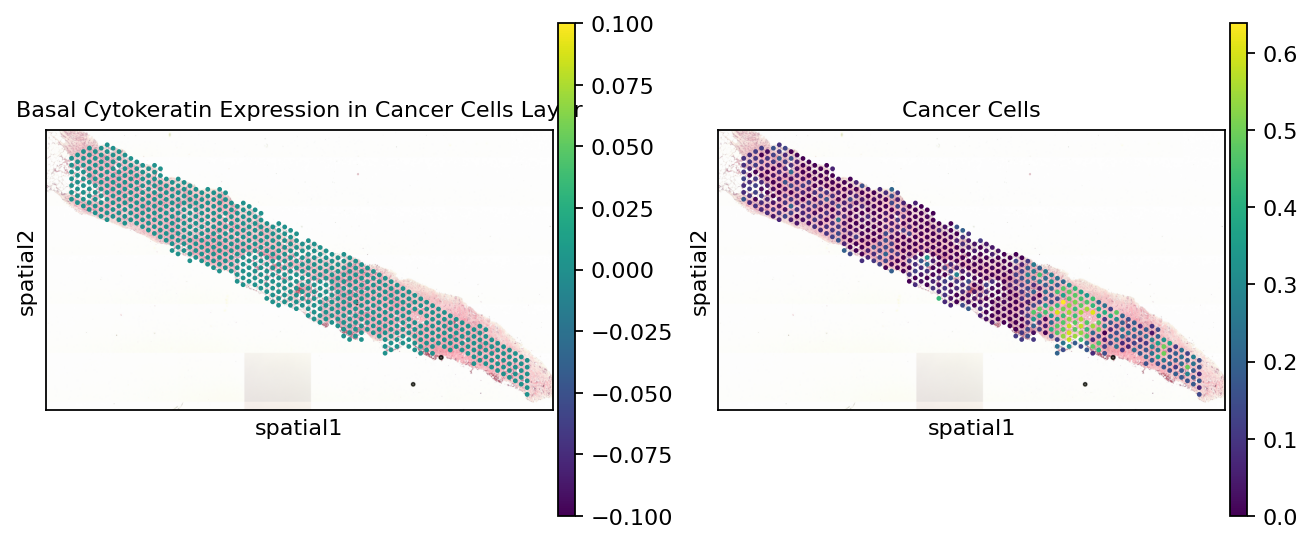

... storing 'feature_types' as categorical
... storing 'genome' as categorical
... storing 'isotype_control' as categorical
... storing 'normalized' as categorical
... storing 'pattern' as categorical
... storing 'read' as categorical
... storing 'secondary_name' as categorical
... storing 'sequence' as categorical


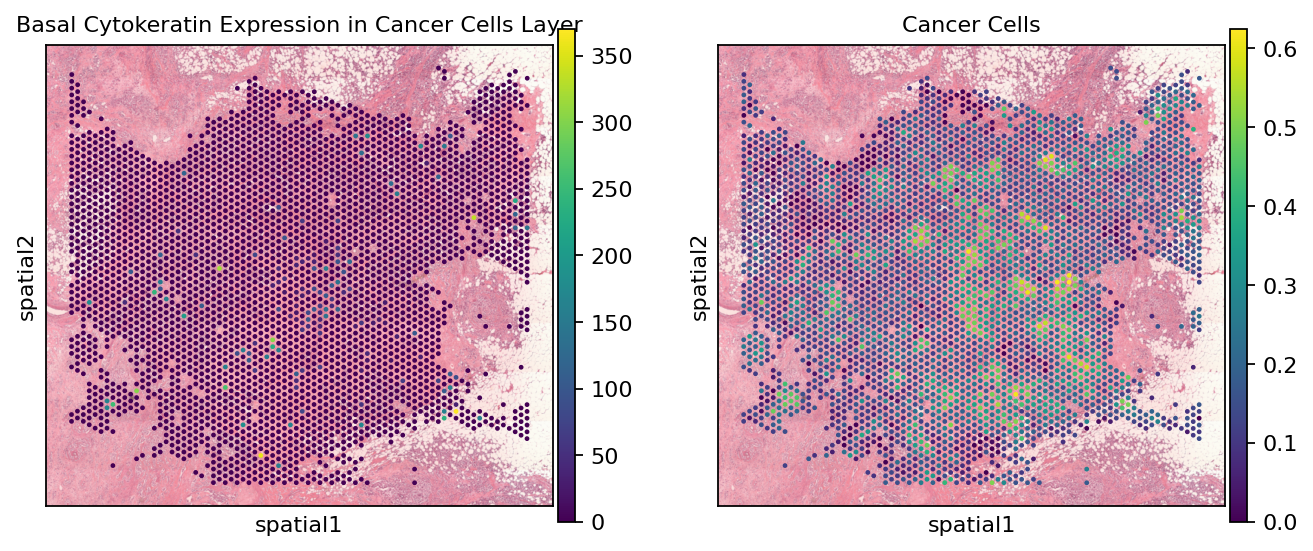

In [46]:
paper_keratins = ["KRT5", "KRT6A", "KRT6B", "KRT14", "KRT16", "KRT17"]

import matplotlib.pyplot as plt

sc.set_figure_params(scanpy=True, fontsize=10)


for sample, adata in prop_gex_adatas.items():
    adata_keratin_list = [gene for gene in adata.var_names if gene.startswith('KRT')]
    intersection = list(set(paper_keratins) & set(adata_keratin_list))
    intersection_idx = [adata.var_names.get_loc(gene) for gene in intersection]
    adata.obs['Basal Cytokeratin Expression'] = adata.layers['Cancer_Cells_genes_pass1'][:, intersection_idx].sum(axis=1)
    sc.pl.spatial(adata, color=['Basal Cytokeratin Expression', 'Cancer Cells'], layer = 'Cancer_Cells_genes_pass1', title = 'Basal Cytokeratin Expression in Cancer Cells Layer')

In [47]:
print(prop_gex_adatas)

{'HCC22-088-P4-S1': AnnData object with n_obs × n_vars = 763 × 2141
    obs: 'in_tissue', 'array_row', 'array_col', 'n_counts', 'size_factors', 'original_total', 'scaled_total', 'Cancer Cells', 'Macrophages', 'CD4 T Cells', 'CD8 T Cells', 'B Cells', 'Endothelial Cells', 'Fibroblasts', 'Basal Cytokeratin Expression'
    var: 'gene_ids', 'feature_types', 'genome', 'isotype_control', 'normalized', 'pattern', 'read', 'secondary_name', 'sequence'
    uns: 'spatial'
    obsm: 'spatial'
    layers: 'CD8_T_Cells_genes_pass1', 'CD4_T_Cells_genes_pass1', 'B_Cells_genes_pass1', 'Endothelial_Cells_genes_pass1', 'Cancer_Cells_genes_pass1', 'Macrophages_genes_pass1', 'Fibroblasts_genes_pass1', 'HCC22-088-P4-S2_1i_rep': AnnData object with n_obs × n_vars = 3370 × 1771
    obs: 'in_tissue', 'array_row', 'array_col', 'n_counts', 'size_factors', 'original_total', 'scaled_total', 'Cancer Cells', 'Macrophages', 'CD4 T Cells', 'CD8 T Cells', 'B Cells', 'Endothelial Cells', 'Fibroblasts', 'Basal Cytokeratin

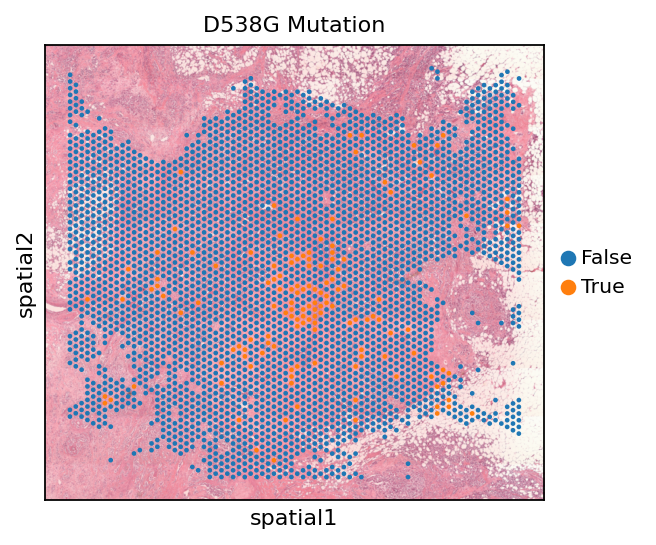

In [48]:
surg_adata = prop_gex_adatas['HCC22-088-P4-S2_1i_rep']
cancer_adata = surg_adata[surg_adata.obs['Cancer Cells'] > 0.2]
surg_adata.obs['D538G Mutation'] = surg_adata.obs['Basal Cytokeratin Expression'] > 0
sc.pl.spatial(surg_adata, color=['D538G Mutation'], title = 'D538G Mutation')

In [49]:
import importlib
import model
importlib.reload(model)
from model.analysis_functions import expand_prop_gex_adata

expanded_adata = expand_prop_gex_adata(surg_adata, celltype_profile_dict=cell_profiles)
print(expanded_adata)

AnnData object with n_obs × n_vars = 5070 × 1771
    obs: 'in_tissue', 'array_row', 'array_col', 'n_counts', 'size_factors', 'original_total', 'scaled_total', 'Cancer Cells', 'Macrophages', 'CD4 T Cells', 'CD8 T Cells', 'B Cells', 'Endothelial Cells', 'Fibroblasts', 'Basal Cytokeratin Expression', 'D538G Mutation', 'celltype'
    var: 'gene_ids', 'feature_types', 'genome', 'isotype_control', 'normalized', 'pattern', 'read', 'secondary_name', 'sequence'
    uns: 'spatial', 'D538G Mutation_colors'
    obsm: 'spatial'
    layers: 'CD8_T_Cells_genes_pass1', 'CD4_T_Cells_genes_pass1', 'B_Cells_genes_pass1', 'Endothelial_Cells_genes_pass1', 'Cancer_Cells_genes_pass1', 'Macrophages_genes_pass1', 'Fibroblasts_genes_pass1'


## Cell-Cell Communication Analysis

Using COMMOT (Cell-Cell Communication Analysis with Spatial Information), we examine how D538G mutations affect cellular communication patterns. This analysis reveals:
- Differential signaling pathways between mutant and wild-type regions
- Spatial organization of cell-cell interactions
- Key ligand-receptor pairs involved in the tumor microenvironment

In [50]:
import commot as ct
import scanpy as sc
import pandas as pd
import numpy as np

In [51]:
df_ligrec=ct.pp.ligand_receptor_database(database='CellChat', species='human')

df_cellchat_filtered = ct.pp.filter_lr_database(df_ligrec, expanded_adata, min_cell_pct=0.01)

print(df_cellchat_filtered)

     0          1    2                   3
0  MIF  CD74_CD44  MIF  Secreted Signaling
1  MDK       SDC4   MK  Secreted Signaling
2  MDK        NCL   MK  Secreted Signaling
3  PTN       SDC4  PTN  Secreted Signaling
4  PTN        NCL  PTN  Secreted Signaling


In [52]:
ct.tl.spatial_communication(expanded_adata, database_name='cellchat', df_ligrec=df_cellchat_filtered, dis_thr=500, heteromeric=True, pathway_sum=False)

In [53]:
sender_signal = expanded_adata.obsm['commot-cellchat-sum-sender']
print(sender_signal.head())

                                 s-PTN-SDC4  s-PTN-NCL  s-MDK-SDC4  s-MDK-NCL  \
AACACGTGCATCGCAC-1_Cancer Cells         0.0        0.0         0.0        0.0   
AACATCGCGTGACCAC-1_Cancer Cells         0.0        0.0         0.0        0.0   
AACCAAGGTATCAGGC-1_Cancer Cells         0.0        0.0         0.0        0.0   
AACCACTGCCATAGCC-1_Cancer Cells         0.0        0.0         0.0        0.0   
AACCGCCAGACTACTT-1_Cancer Cells         0.0        0.0         0.0        0.0   

                                 s-MIF-CD74_CD44  s-total-total  
AACACGTGCATCGCAC-1_Cancer Cells              0.0            0.0  
AACATCGCGTGACCAC-1_Cancer Cells              0.0            0.0  
AACCAAGGTATCAGGC-1_Cancer Cells              0.0            0.0  
AACCACTGCCATAGCC-1_Cancer Cells              0.0            0.0  
AACCGCCAGACTACTT-1_Cancer Cells              0.0            0.0  


In [54]:
# Calculate the mean of each column
series = sender_signal.mean()
# Filter columns with non-zero means
nonzero_series = series[series != 0]

# Sort columns by mean values in descending order
nonzero_series.sort_values(ascending=False, inplace=True)

nonzero_series.head(20)

s-total-total      4.703846
s-MDK-SDC4         1.467587
s-PTN-SDC4         1.066922
s-PTN-NCL          0.859389
s-MDK-NCL          0.781743
s-MIF-CD74_CD44    0.528205
dtype: float64

In [55]:
cancer_adata = expanded_adata[expanded_adata.obs['celltype'] == 'Cancer Cells']

print(cancer_adata)

View of AnnData object with n_obs × n_vars = 1210 × 1771
    obs: 'in_tissue', 'array_row', 'array_col', 'n_counts', 'size_factors', 'original_total', 'scaled_total', 'Cancer Cells', 'Macrophages', 'CD4 T Cells', 'CD8 T Cells', 'B Cells', 'Endothelial Cells', 'Fibroblasts', 'Basal Cytokeratin Expression', 'D538G Mutation', 'celltype'
    var: 'gene_ids', 'feature_types', 'genome', 'isotype_control', 'normalized', 'pattern', 'read', 'secondary_name', 'sequence'
    uns: 'spatial', 'D538G Mutation_colors', 'commot-cellchat-info'
    obsm: 'spatial', 'commot-cellchat-sum-sender', 'commot-cellchat-sum-receiver'
    layers: 'CD8_T_Cells_genes_pass1', 'CD4_T_Cells_genes_pass1', 'B_Cells_genes_pass1', 'Endothelial_Cells_genes_pass1', 'Cancer_Cells_genes_pass1', 'Macrophages_genes_pass1', 'Fibroblasts_genes_pass1'
    obsp: 'commot-cellchat-PTN-SDC4', 'commot-cellchat-PTN-NCL', 'commot-cellchat-MDK-SDC4', 'commot-cellchat-MDK-NCL', 'commot-cellchat-MIF-CD74_CD44', 'commot-cellchat-total-total'

In [56]:
sender_signal = cancer_adata.obsm['commot-cellchat-sum-sender']

In [57]:
# Get sender signals for D538G mutation True and False cells
d538g_true_signals = sender_signal[cancer_adata.obs['D538G Mutation'] == True]
d538g_false_signals = sender_signal[cancer_adata.obs['D538G Mutation'] == False]

# Perform Mann-Whitney U test for each pathway
from scipy import stats
import pandas as pd
from statsmodels.stats.multitest import fdrcorrection

pathway_pvals = {}
pathway_stats = {}

for pathway in sender_signal.columns:
    try:
        # Remove NaN values
        true_data = d538g_true_signals[pathway].dropna()
        false_data = d538g_false_signals[pathway].dropna()
        
        if len(true_data) == 0 or len(false_data) == 0:
            print(f"Warning: Empty group for pathway {pathway}")
            continue
            
        stat, pval = stats.mannwhitneyu(
            true_data,
            false_data,
            alternative='two-sided'
        )
        pathway_pvals[pathway] = pval
        pathway_stats[pathway] = stat
    except Exception as e:
        print(f"Error processing pathway {pathway}: {str(e)}")
        continue

# Create DataFrame with results
results_df = pd.DataFrame({
    'Pathway': pathway_pvals.keys(),
    'P-value': pathway_pvals.values(),
    'Statistic': pathway_stats.values()
})

# Add mean difference between groups
results_df['Mean_Diff'] = [
    d538g_true_signals[pathway].mean() - d538g_false_signals[pathway].mean()
    for pathway in pathway_pvals.keys()
]

# Sort by p-value
results_df = results_df.sort_values('P-value')

# Apply Benjamini-Hochberg correction
_, fdr_corrected = fdrcorrection(results_df['P-value'])
results_df['FDR'] = fdr_corrected

# Filter for significant pathways (FDR < 0.05)
significant_pathways = results_df[results_df['FDR'] < 0.05]
print("\nSignificantly different pathways between D538G mutation True and False cells:")
print(significant_pathways)


Significantly different pathways between D538G mutation True and False cells:
           Pathway       P-value  Statistic  Mean_Diff           FDR
0       s-PTN-SDC4  2.097529e-34    68175.0   5.606475  1.258517e-33
5    s-total-total  2.374654e-33    78855.0  15.316155  7.123962e-33
1        s-PTN-NCL  6.883493e-26    65029.0   1.860357  1.376699e-25
3        s-MDK-NCL  1.031089e-15    69148.0   1.312028  1.546634e-15
2       s-MDK-SDC4  4.681206e-15    69594.0   5.334956  5.617447e-15
4  s-MIF-CD74_CD44  8.054256e-05    60251.0   1.202339  8.054256e-05



Summary Statistics:

Pathway: s-PTN-SDC4
------------------
D538G Mutant: Mean = 5.994 ± 2.140 SEM
D538G Wild-type: Mean = 0.388 ± 0.174 SEM
FDR-adjusted p-value: 1.26e-33

Pathway: s-total-total
------------------
D538G Mutant: Mean = 18.948 ± 3.123 SEM
D538G Wild-type: Mean = 3.632 ± 0.574 SEM
FDR-adjusted p-value: 7.12e-33

Pathway: s-PTN-NCL
------------------
D538G Mutant: Mean = 2.025 ± 0.710 SEM
D538G Wild-type: Mean = 0.165 ± 0.097 SEM
FDR-adjusted p-value: 1.38e-25

Pathway: s-MDK-NCL
------------------
D538G Mutant: Mean = 1.956 ± 0.596 SEM
D538G Wild-type: Mean = 0.644 ± 0.179 SEM
FDR-adjusted p-value: 1.55e-15

Pathway: s-MDK-SDC4
------------------
D538G Mutant: Mean = 7.452 ± 1.666 SEM
D538G Wild-type: Mean = 2.117 ± 0.362 SEM
FDR-adjusted p-value: 5.62e-15

Pathway: s-MIF-CD74_CD44
------------------
D538G Mutant: Mean = 1.520 ± 0.618 SEM
D538G Wild-type: Mean = 0.318 ± 0.110 SEM
FDR-adjusted p-value: 8.05e-05


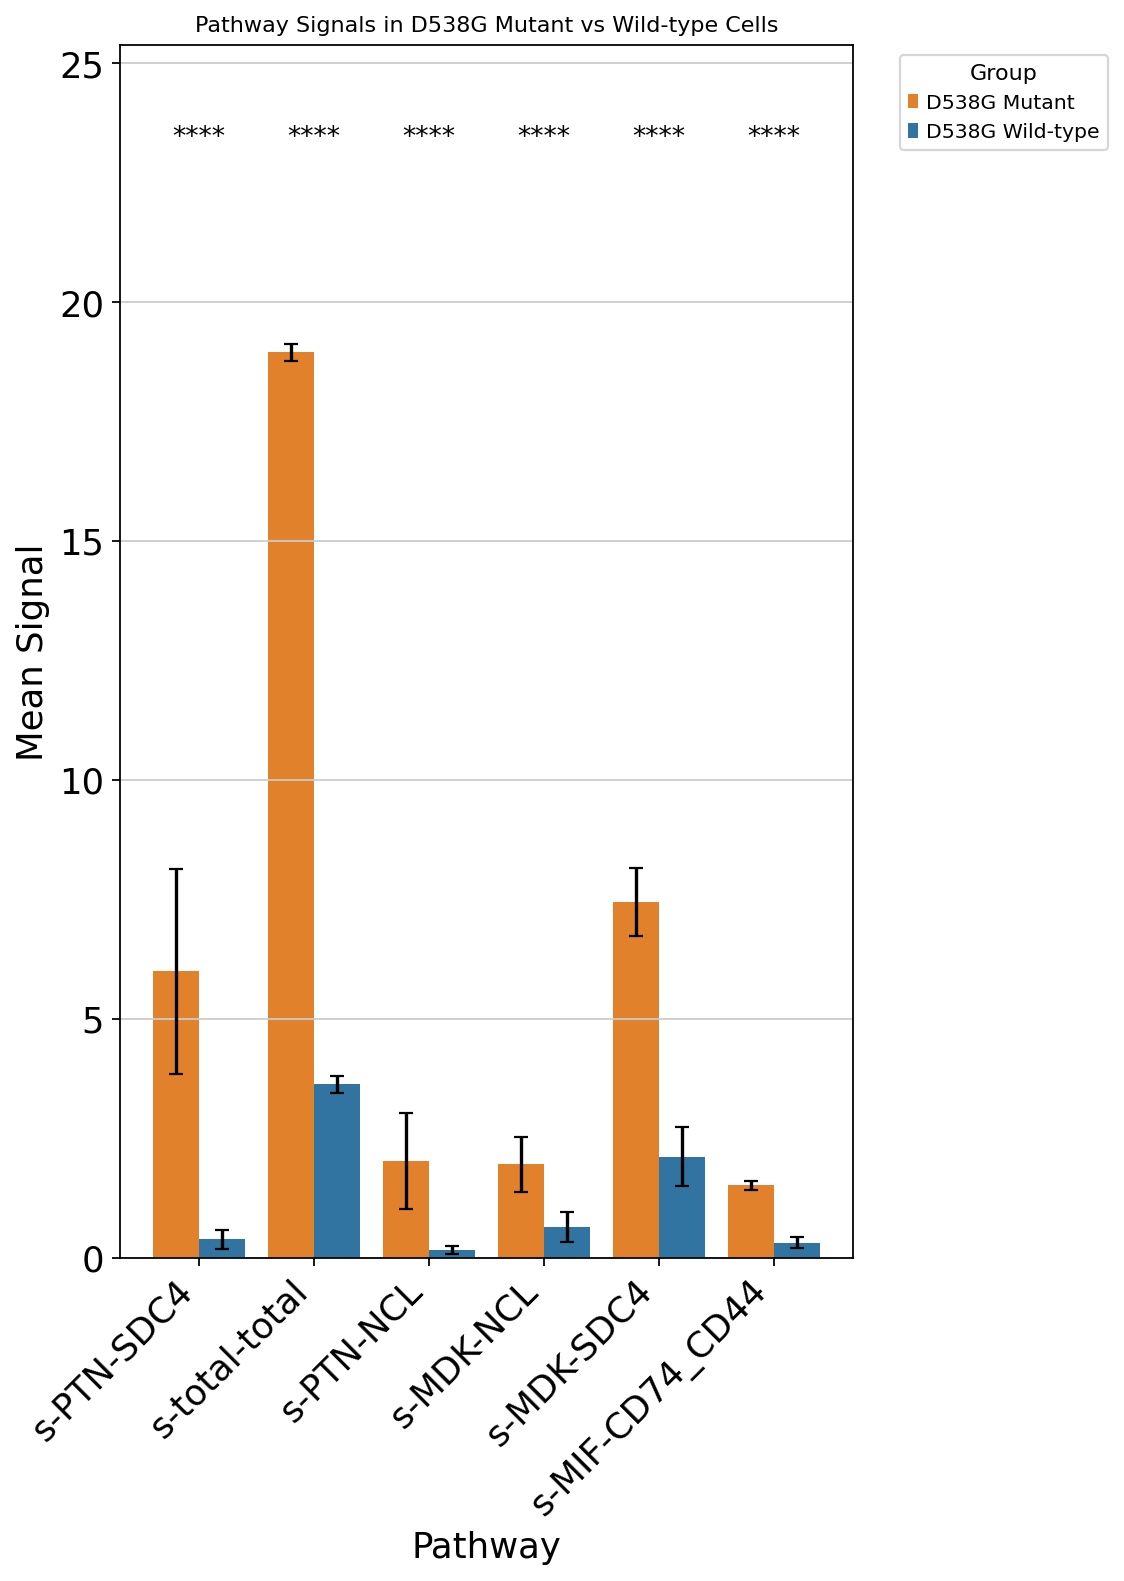

In [58]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# Define explicit orders
pathway_order = significant_pathways['Pathway'].tolist()
group_order = ['D538G Mutant', 'D538G Wild-type']

# Build the plot_data DataFrame
plot_data = pd.DataFrame()
for pathway in pathway_order:
    temp = pd.DataFrame({
        'Pathway': [pathway, pathway],
        'Group': group_order,
        'Mean Signal': [
            d538g_true_signals[pathway].mean(),
            d538g_false_signals[pathway].mean()
        ],
        'SEM': [
            d538g_true_signals[pathway].sem(),
            d538g_false_signals[pathway].sem()
        ]
    })
    plot_data = pd.concat([plot_data, temp], ignore_index=True)

# Print summary statistics
print("\nSummary Statistics:")
print("==================")
for pathway in pathway_order:
    print(f"\nPathway: {pathway}")
    print("------------------")
    # Get statistics for mutant
    mutant_mean = plot_data[(plot_data['Pathway'] == pathway) & (plot_data['Group'] == 'D538G Mutant')]['Mean Signal'].iloc[0]
    mutant_sem = plot_data[(plot_data['Pathway'] == pathway) & (plot_data['Group'] == 'D538G Mutant')]['SEM'].iloc[0]
    # Get statistics for wild-type
    wt_mean = plot_data[(plot_data['Pathway'] == pathway) & (plot_data['Group'] == 'D538G Wild-type')]['Mean Signal'].iloc[0]
    wt_sem = plot_data[(plot_data['Pathway'] == pathway) & (plot_data['Group'] == 'D538G Wild-type')]['SEM'].iloc[0]
    # Get p-value
    pval = significant_pathways.loc[significant_pathways['Pathway'] == pathway, 'FDR'].iloc[0]
    
    print(f"D538G Mutant: Mean = {mutant_mean:.3f} ± {mutant_sem:.3f} SEM")
    print(f"D538G Wild-type: Mean = {wt_mean:.3f} ± {wt_sem:.3f} SEM")
    print(f"FDR-adjusted p-value: {pval:.2e}")

# Set figure size - adjust width and height for vertical orientation
plt.figure(figsize=(len(pathway_order) * 1.2, 10))

# Create the vertical bar plot
ax = sns.barplot(
    data=plot_data,
    x='Pathway',  # Swap x and y
    y='Mean Signal',  # Swap x and y
    hue='Group',
    order=pathway_order,
    hue_order=group_order,
    palette=['#ff7f0e', '#1f77b4'],
    ci=None
)

def get_stars(pval):
    if pval <= 0.0001:
        return "****"
    elif pval <= 0.001:
        return "***"
    elif pval <= 0.01:
        return "**"
    elif pval <= 0.05:
        return "*"
    return "ns"

# Add error bars
for idx, patch in enumerate(ax.patches[:len(plot_data)]):
    sem = plot_data.iloc[idx]['SEM']
    x_center = patch.get_x() + patch.get_width() / 2
    y_center = patch.get_height()
    
    # Clip extremely large error bars
    max_sem = y_center * 0.5  # Limit SEM to 50% of the mean
    sem = min(sem, max_sem)
    
    ax.errorbar(
        x=x_center,
        y=y_center,
        yerr=sem,  # Use yerr instead of xerr for vertical bars
        fmt='none',
        ecolor='black',
        capsize=3,
        capthick=1,
        zorder=10
    )

# Find the maximum y value across all bars and error bars
max_y = max([
    row['Mean Signal'] + row['SEM']
    for _, row in plot_data.iterrows()
])

# Add significance stars
for i, pathway in enumerate(pathway_order):
    pval = significant_pathways.loc[significant_pathways['Pathway'] == pathway, 'FDR'].iloc[0]
    stars = get_stars(pval)
    
    # Place stars above the bars
    pathway_data = plot_data[plot_data['Pathway'] == pathway]
    max_height = pathway_data['Mean Signal'].max() + pathway_data['SEM'].max()
    
    ax.text(
        i,  # X position at the center of the pathway
        max_y * 1.05,  # Fixed position above the highest bar
        stars,
        ha='center',  # Center horizontally
        va='bottom',  # Align to bottom
        fontsize=12,
        color='black'
    )

# Set y-axis limit to include stars
plt.ylim(0, max_y * 1.15)

# Rotate x-axis labels for better readability
plt.xticks(rotation=45, ha='right', fontsize=16)
plt.yticks(fontsize=16)

# Customize plot
plt.title('Pathway Signals in D538G Mutant vs Wild-type Cells')
plt.ylabel('Mean Signal', fontsize=16)
plt.xlabel('Pathway', fontsize=16)  # Remove x-label since pathway names are self-explanatory

# Move legend outside
plt.legend(title='Group', bbox_to_anchor=(1.05, 1), loc='upper left')

# Adjust layout
plt.tight_layout()

# Save and show
plt.savefig('pathway_signals.svg', bbox_inches='tight', dpi=300)
plt.show()

In [59]:
import scanpy as sc
import scanpy as sc
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
from scipy.spatial import KDTree
from collections import Counter
import pandas as pd

def assign_radial_regions(adata, cancer_type, mask_label = 'classification',  distance=8, num_regions=5):
    # Filter for the specific cancer type
    cancer_mask = adata.obs[mask_label] == cancer_type
    cancer_coords = adata.obsm['spatial'][cancer_mask]
    
    if len(cancer_coords) == 0:
        print(f"No {cancer_type} cells found.")
        return adata
    
    # Create a KD-tree for efficient nearest neighbor search
    tree = KDTree(cancer_coords)
    
    # Query the tree for all points
    distances, _ = tree.query(adata.obsm['spatial'], k=1)
    
    # Define region labels and conditions
    region_labels = [0] + [distance * (i + 1) for i in range(num_regions)]
    conditions = [cancer_mask] + [(distance * i < distances) & (distances <= distance * (i + 1)) for i in range(num_regions)]
    
    # Assign regions based on distances
    adata.obs[f'{cancer_type}_region'] = np.select(
        conditions,
        region_labels,
        default=-1
    ).astype(int)
    
    return adata


In [60]:
def plot_cancer_regions(adata, cancer_type):
    # Create a new figure
    fig, ax = plt.subplots(figsize=(12, 10))
    
    # Define color map with a colormap
    unique_regions = np.sort(adata.obs[f'{cancer_type}_region'].unique())
    colors = plt.cm.Spectral(np.linspace(0, 1, len(unique_regions)))
    color_map = dict(zip(unique_regions, colors))

    # First, let's determine the boundaries of our data
    min_x = adata.obsm['spatial'][:, 0].min()
    max_x = adata.obsm['spatial'][:, 0].max()
    min_y = adata.obsm['spatial'][:, 1].min()
    max_y = adata.obsm['spatial'][:, 1].max()

    
    # Plot spatial distribution
    sc.pl.spatial(adata, 
                  color=f'{cancer_type}_region', 
                  color_map="Spectral",
                  spot_size=5, 
                  ax=ax,
                  crop_coord=(min_x, max_x, min_y, max_y),
                  show=False,
                  #legend_loc='right'
                  
                 )
    
    # Set title
    ax.set_title(f'Spatial distribution of {cancer_type} and surrounding regions')
    
    plt.tight_layout()
    plt.show()

In [61]:
# Strip the _Cancer_Cells off the .obs_names of cancer_adata
cancer_adata.obs_names = cancer_adata.obs_names.str.replace('_Cancer Cells', '')
print(cancer_adata.obs_names)

Index(['AACACGTGCATCGCAC-1', 'AACATCGCGTGACCAC-1', 'AACCAAGGTATCAGGC-1',
       'AACCACTGCCATAGCC-1', 'AACCGCCAGACTACTT-1', 'AACCGTGCTTATGTTG-1',
       'AACCTACAGAGGTAGT-1', 'AACGAATTGACCGGTT-1', 'AACGACATTAAGATGG-1',
       'AACGAGCTAATAACTA-1',
       ...
       'TGTCATGCATGAGCAC-1', 'TGTCCATGTATGGAAT-1', 'TGTCGAGTGCGTTAGC-1',
       'TGTCTTGCGACTAATT-1', 'TGTCTTGGAATTGGCA-1', 'TGTTACCTATTGGACA-1',
       'TGTTCTGCTCTGTCGT-1', 'TGTTGGAACCTTCCGC-1', 'TGTTGGAACGAGGTCA-1',
       'TGTTGGCCAGACCTAC-1'],
      dtype='object', length=1210)


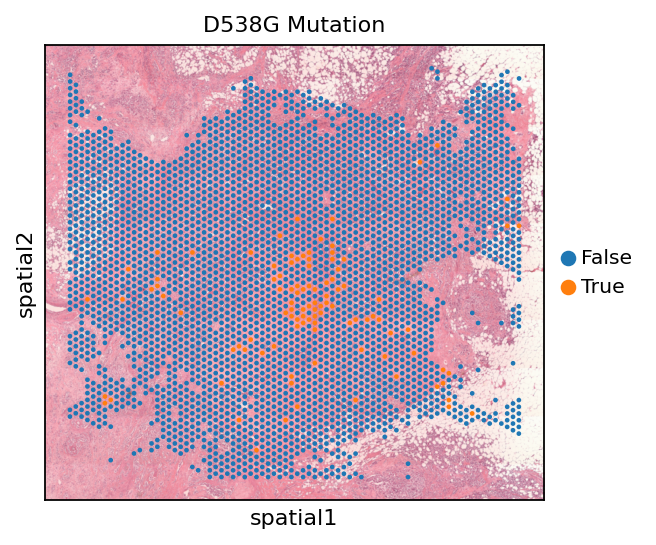

... storing 'celltype' as categorical


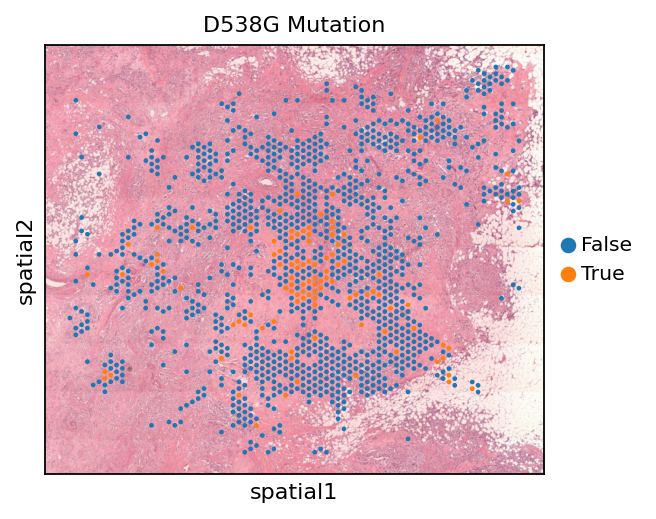

In [62]:
# First initialize all values as False
surg_adata.obs['D538G Mutation'] = False

# Then update only the matching indices from cancer_adata
surg_adata.obs.loc[cancer_adata.obs.index, 'D538G Mutation'] = cancer_adata.obs['D538G Mutation']

# Now plot (should work without NaN errors)
sc.pl.spatial(surg_adata, color='D538G Mutation', title='D538G Mutation')
sc.pl.spatial(cancer_adata, color='D538G Mutation', title='D538G Mutation')

# Make sure it's boolean type and save
surg_adata.obs['D538G Mutation'] = surg_adata.obs['D538G Mutation'].astype(bool)
surg_adata.write_h5ad('surg_adata_wMutation.h5ad')

## Radial Region Analysis

To understand how the tumor microenvironment changes with distance from D538G mutant regions, we:
1. Define concentric regions around mutant areas
2. Analyze gene expression patterns in each region
3. Perform pathway enrichment analysis to identify biological processes that change with distance from mutant cells

In [63]:
# Add radial regions and classifications

expanded_adata = assign_radial_regions(surg_adata, cancer_type = True, mask_label = 'D538G Mutation', distance=50, num_regions=8)

print(expanded_adata)


AnnData object with n_obs × n_vars = 3370 × 1771
    obs: 'in_tissue', 'array_row', 'array_col', 'n_counts', 'size_factors', 'original_total', 'scaled_total', 'Cancer Cells', 'Macrophages', 'CD4 T Cells', 'CD8 T Cells', 'B Cells', 'Endothelial Cells', 'Fibroblasts', 'Basal Cytokeratin Expression', 'D538G Mutation', 'True_region'
    var: 'gene_ids', 'feature_types', 'genome', 'isotype_control', 'normalized', 'pattern', 'read', 'secondary_name', 'sequence'
    uns: 'spatial', 'D538G Mutation_colors'
    obsm: 'spatial'
    layers: 'CD8_T_Cells_genes_pass1', 'CD4_T_Cells_genes_pass1', 'B_Cells_genes_pass1', 'Endothelial_Cells_genes_pass1', 'Cancer_Cells_genes_pass1', 'Macrophages_genes_pass1', 'Fibroblasts_genes_pass1'


In [64]:
print(expanded_adata.obs['True_region'].unique())

[ -1 350 150 200 300 100 400 250   0]


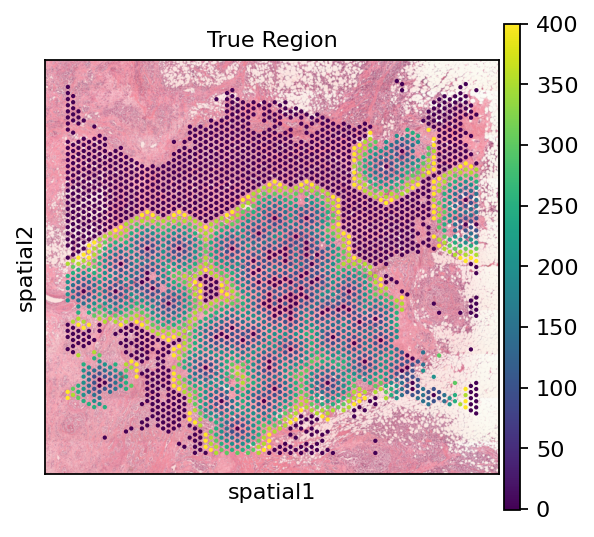

In [65]:
sc.pl.spatial(expanded_adata, color = 'True_region', title = 'True Region')

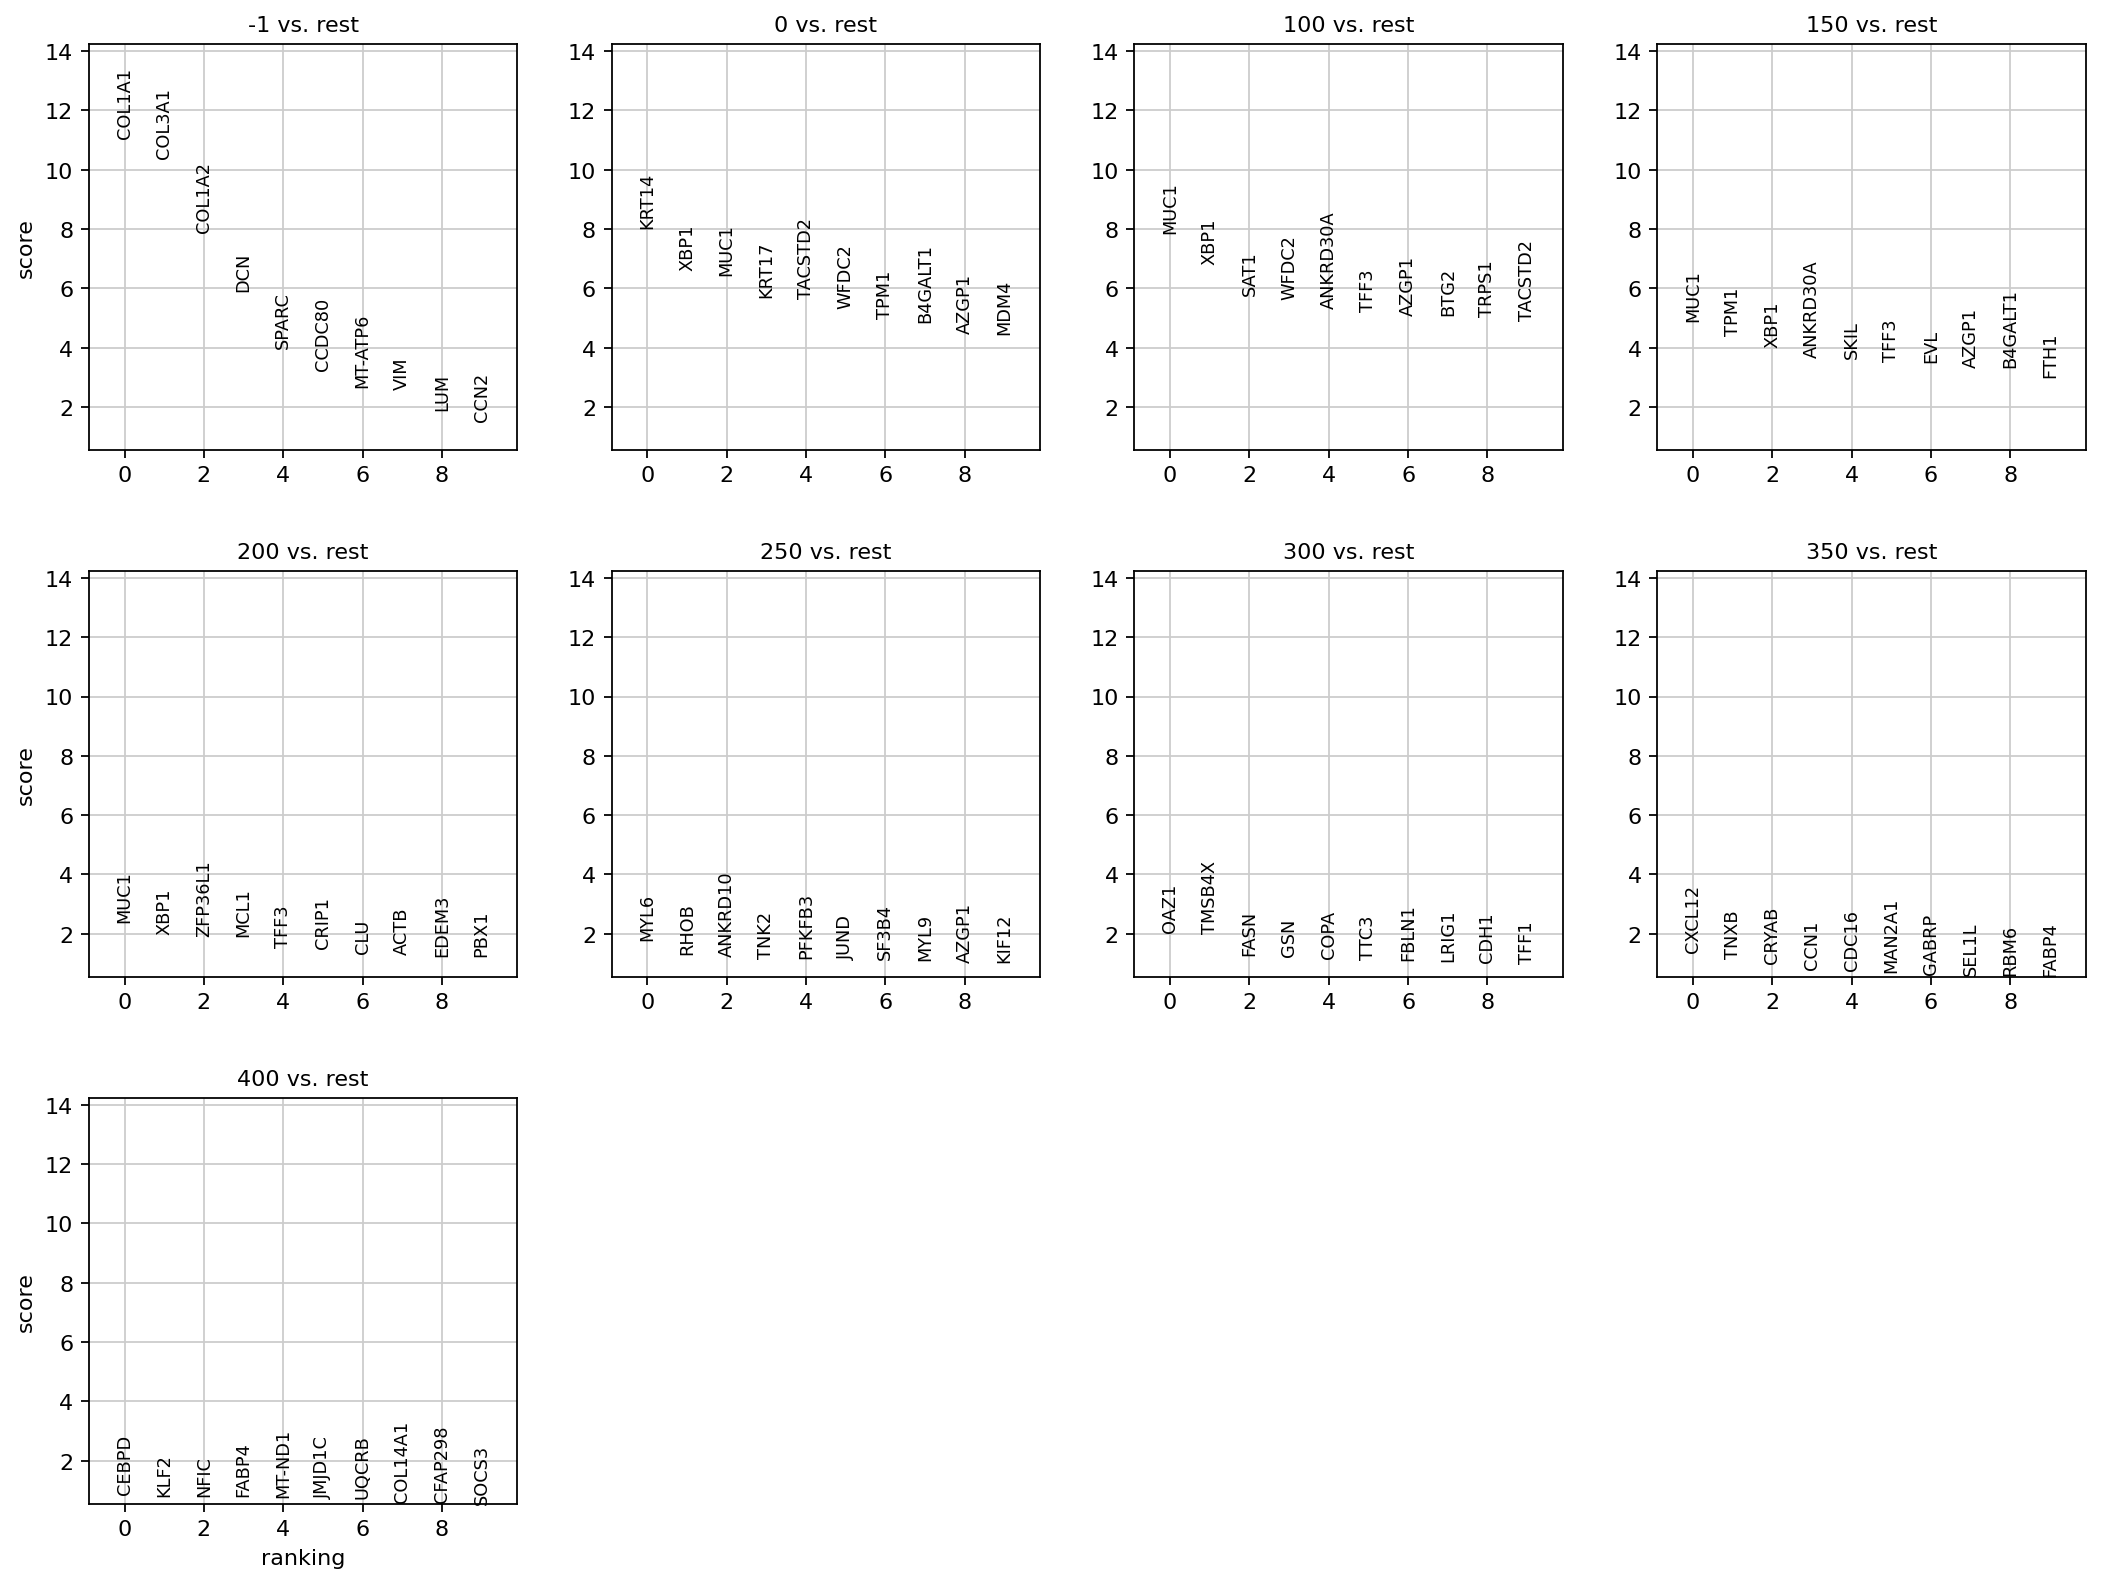

In [66]:
# Convert True_region to categorical
expanded_adata.obs['True_region'] = expanded_adata.obs['True_region'].astype('category')
sc.pp.log1p(expanded_adata)
# Now run the differential expression analysis
sc.tl.rank_genes_groups(expanded_adata, 'True_region', method='wilcoxon')
sc.pl.rank_genes_groups(expanded_adata, n_genes=10)

     names    scores  logfoldchanges         pvals     pvals_adj
0    KRT14  8.015365        3.741583  1.098107e-15  1.944747e-12
1     XBP1  6.598212        2.955932  4.161464e-11  3.684976e-08
2     MUC1  6.458012        2.914724  1.060876e-10  6.262702e-08
3    KRT17  5.689137        3.122592  1.276827e-08  5.337316e-06
4  TACSTD2  5.660780        2.637016  1.506865e-08  5.337316e-06
Number of genes in the group:  45
                Gene_set                               Term Overlap  \
0   MSigDB_Hallmark_2020            Estrogen Response Early  10/200   
1   MSigDB_Hallmark_2020                          Apoptosis   9/161   
2   MSigDB_Hallmark_2020      TNF-alpha Signaling via NF-kB   7/200   
3   MSigDB_Hallmark_2020             Estrogen Response Late   7/200   
4   MSigDB_Hallmark_2020                        p53 Pathway   6/200   
5   MSigDB_Hallmark_2020               IL-2/STAT5 Signaling   4/199   
6   MSigDB_Hallmark_2020                            Hypoxia   4/200   
7   MSig

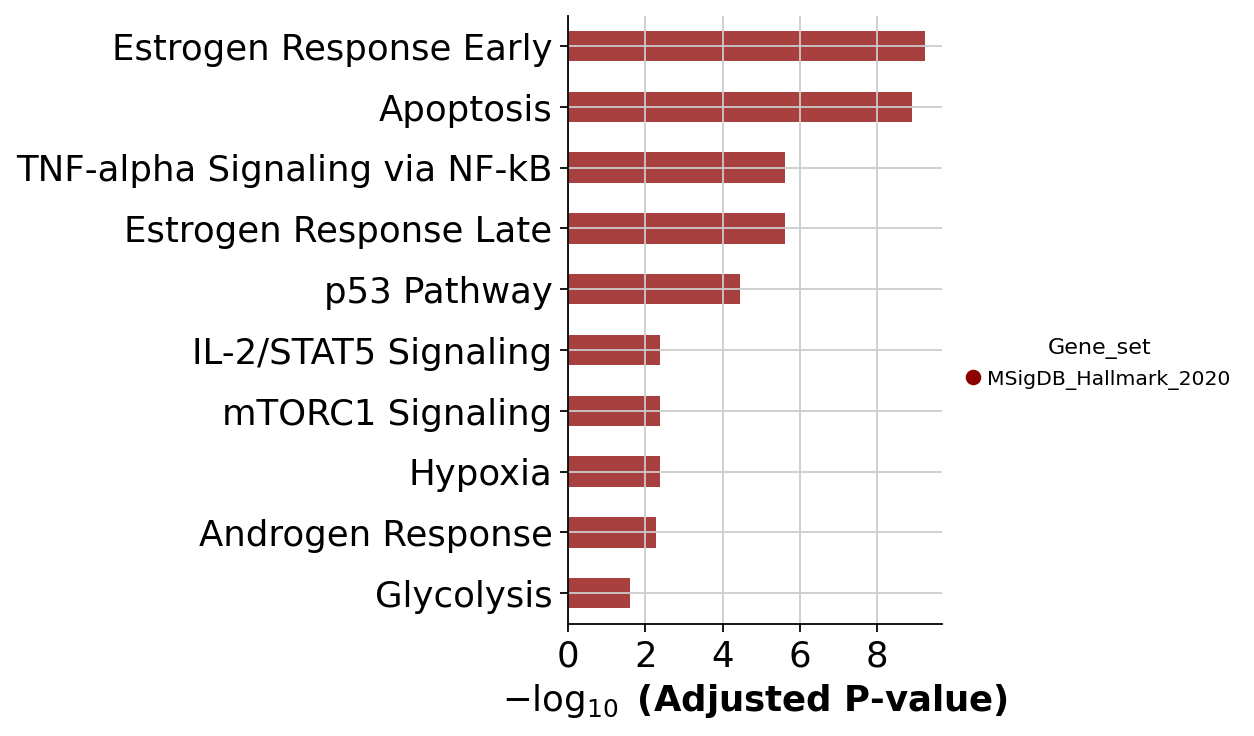

In [67]:
import gseapy as gp

results = expanded_adata.uns['rank_genes_groups']

distance = '0'

"""
geneset_list = ['KEGG_2021_Human','BioCarta_2016', 'MSigDB_Hallmark_2020', 'Reactome_2022',
                'CellMarker_2024', 'CellMarker_Augmented_2021']
"""

gene_set_list = ['MSigDB_Hallmark_2020', 'KEGG_2021_Human']

color=['darkred', 'darkblue']

for num, gene_set in enumerate(gene_set_list):
    groups = results['names'].dtype.names

    dataframes_dict = {}
    for group in groups:
        df = pd.DataFrame({
            'names': results['names'][group],
            'scores': results['scores'][group],
            'logfoldchanges': results['logfoldchanges'][group],
            'pvals': results['pvals'][group],
            'pvals_adj': results['pvals_adj'][group]
        })
        dataframes_dict[group] = df

    df_of_interest = dataframes_dict[distance] # Go to 16, it's clear the 8 is still too close and has cancer cells in it.

    group_df = df_of_interest

    print(group_df.head())

    group_df = group_df[group_df[f'scores']  > 0]

    group_df = group_df[group_df[f'pvals_adj'] < 0.05]

    group_df = group_df[group_df[f'logfoldchanges'] > 0]

    gene_list = group_df['names'].tolist()

    print("Number of genes in the group: ", len(gene_list))

    if len(gene_list) == 0:
        print("No significant pathways found for ", gene_set)
        continue

    try:
        enr = gp.enrichr(gene_list=gene_list, 
                            gene_sets=gene_set,
                            organism='Human', # or 'Mouse' for mouse genes
                            outdir='enrichr_kegg')
        print(enr.results)


        # categorical scatterplot
        ax = gp.barplot(enr.results,
                    column="Adjusted P-value",
                    group='Gene_set', # set group, so you could do a multi-sample/library comparsion
                    size=10,
                    top_term=10,
                    figsize=(3,5),
                    color=color[num] # set colors for group
                    )
        plt.savefig(f"{gene_set}_barplot.svg")
    except ValueError:
        print("No significant pathways found for ", gene_set)
    
# Could also try pathway analysis off of this. 

In [68]:
print(cancer_adata.obs['D538G Mutation'])

AACACGTGCATCGCAC-1    False
AACATCGCGTGACCAC-1    False
AACCAAGGTATCAGGC-1    False
AACCACTGCCATAGCC-1    False
AACCGCCAGACTACTT-1    False
                      ...  
TGTTACCTATTGGACA-1    False
TGTTCTGCTCTGTCGT-1    False
TGTTGGAACCTTCCGC-1    False
TGTTGGAACGAGGTCA-1    False
TGTTGGCCAGACCTAC-1    False
Name: D538G Mutation, Length: 1210, dtype: bool


## ESR1 Mutation Signature Validation

We validate our findings using an established ESR1 mutation gene signature. This analysis:
1. Compares expression patterns between mutant and wild-type regions
2. Calculates signature scores based on up- and down-regulated genes
3. Provides statistical validation of the mutation identification approach

The results demonstrate clear differentiation between mutant and wild-type regions, supporting the accuracy of our spatial analysis approach.

In [69]:
import pandas as pd
import scanpy as sc
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import ttest_ind
from scipy import stats


# Set fontsize for all plots in matplotlib
plt.rcParams.update({'font.size': 20})


# ============ STEP 1: Read gene lists from Excel ============

try:
    df = pd.read_excel("examples/media-3.xlsx", sheet_name=0)
except FileNotFoundError as e:
    print("[DEBUG] Could not find the file 'examples/media-3.xlsx'. Please check your filepath.")
    raise e

# Column headers in the first sheet should match exactly:
up_col = "Up genes in ESR1 mutant within top 10% and consistent in at least 40% comaparisons"
down_col = "Down genes in ESR1 mutant within top 10% and consistent in at least 40% comaparisons"

if up_col not in df.columns or down_col not in df.columns:
    print(f"[DEBUG] Expected columns '{up_col}' and/or '{down_col}' are not found in the Excel file.")
    print("[DEBUG] Available columns:", df.columns.tolist())
    raise ValueError("Mismatched column headers.")

# Extract gene lists and drop any blank cells
up_genes = df[up_col].dropna().tolist()
down_genes = df[down_col].dropna().tolist()

print("[DEBUG] Number of Up genes read:", len(up_genes))
print("[DEBUG] Number of Down genes read:", len(down_genes))

# ============ STEP 2: Filter by genes present in cancer_adata ============

genes_in_adata = set(cancer_adata.var_names)
up_genes_filtered = list(genes_in_adata.intersection(up_genes))
down_genes_filtered = list(genes_in_adata.intersection(down_genes))

if not up_genes_filtered:
    print("[DEBUG] No Up genes matched between Excel and cancer_adata.var_names.")
if not down_genes_filtered:
    print("[DEBUG] No Down genes matched between Excel and cancer_adata.var_names.")

print("[DEBUG] Number of Up genes matched to adata:", len(up_genes_filtered))
print("[DEBUG] Number of Down genes matched to adata:", len(down_genes_filtered))

# ============ STEP 4: Compute the ESR1 signature score for each spot ============

try:
    # Mean expression of the Up genes across each spot
    up_expr = cancer_adata[:, up_genes_filtered].X.mean(axis=1)
    # Mean expression of the Down genes across each spot
    down_expr = cancer_adata[:, down_genes_filtered].X.mean(axis=1)
except KeyError as e:
    print("[DEBUG] One or more specified genes not found in adata. Possibly a mismatch in var_names.")
    raise e

# Subtract: Up - Down
esr1_score = up_expr - down_expr

# Add this to .obs for downstream visualization
cancer_adata.obs["ESR1_signature_score"] = esr1_score

# ============ STEP 5: Compare mutant vs. wild-type ============

# Boolean column in .obs
if "D538G Mutation" not in cancer_adata.obs.columns:
    print("[DEBUG] The .obs does not contain 'D538G Mutation'. Check your adata.obs columns:")
    print("[DEBUG] Observed columns:", cancer_adata.obs.columns.tolist())
    raise ValueError("Missing 'D538G Mutation' in .obs.")

mut_mask = cancer_adata.obs["D538G Mutation"] == True
wt_mask = cancer_adata.obs["D538G Mutation"] == False

mut_scores = cancer_adata.obs.loc[mut_mask, "ESR1_signature_score"]
wt_scores = cancer_adata.obs.loc[wt_mask, "ESR1_signature_score"]

# Get n numbers
n_mut = len(mut_scores)
n_wt = len(wt_scores)

# Basic t-test (unequal variance)
stat, pval = ttest_ind(mut_scores, wt_scores, equal_var=False)

# Calculate confidence intervals
mut_ci = stats.t.interval(alpha=0.95, df=len(mut_scores)-1, loc=np.mean(mut_scores), scale=stats.sem(mut_scores))
wt_ci = stats.t.interval(alpha=0.95, df=len(wt_scores)-1, loc=np.mean(wt_scores), scale=stats.sem(wt_scores))

print(f"[DEBUG] T-test statistic={stat:.4f}, p-value={pval:.4e}")
print("[DEBUG] Mean ESR1 signature score in mutants:", mut_scores.mean())
print("[DEBUG] 95% CI for mutants: ({:.4f}, {:.4f})".format(mut_ci[0], mut_ci[1]))
print("[DEBUG] Mean ESR1 signature score in wild-type:", wt_scores.mean())
print("[DEBUG] 95% CI for wild-type: ({:.4f}, {:.4f})".format(wt_ci[0], wt_ci[1]))

# Create a DataFrame for seaborn plotting
plot_df = pd.DataFrame({
    'Score': pd.concat([mut_scores, wt_scores]),
    'Group': ['ESR1 Mutant']*n_mut + ['Wild-Type']*n_wt
})

# Box and swarm plot
plt.figure(figsize=(5, 5))
# Use two colors from viridis palette
colors = ['#440154', '#21918c'] # Dark purple and teal from viridis
sns.boxplot(data=plot_df, x='Group', y='Score', palette=colors)
sns.swarmplot(data=plot_df, x='Group', y='Score', color='black', size=4, alpha=0.3)
plt.title(f"ESR1 Mutant Signature Score\nT-test p = {pval:.4e}")
plt.ylabel("Score (Up - Down)")
plt.xticks(range(2), [f"ESR1 Mutant\n(n={n_mut})", f"Wild-Type\n(n={n_wt})"])
plt.savefig("ESR1 mutant pathway score.svg")
plt.show()


ImportError: Missing optional dependency 'openpyxl'.  Use pip or conda to install openpyxl.